In [1]:
import os
os.chdir("/Users/karanrnaik/Desktop/earnings_analyzer")
print("✅ Working directory:", os.getcwd())

✅ Working directory: /Users/karanrnaik/Desktop/earnings_analyzer


In [2]:
import subprocess

subprocess.run(["pip", "install", "transformers"])
subprocess.run(["pip", "install", "torch"])
subprocess.run(["pip", "install", "bertopic"])
subprocess.run(["pip", "install", "sentence-transformers"])

print("✅ All libraries installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 2.1 MB/s  0:00:05m 2.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 1.6 MB/s  0:00:002.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 2.0 MB/s  0:00:012.0 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 3.6 MB/s  0:00:00m 3.6 MB/s eta 0:00:01
  Attempting uninstall: regex
    Found existing installation: regex 2025.9.1
    Uninstalling regex-2025.9.1:
      Successfully uninstalled regex-2025.9.1
  Attempting uninstall: click
    Found existing installation: click 8.2.138;5;237m╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [click]
    Uninstalling click-8.2.1:━━━━━╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [click]
      Successfully uninstalled click-8.2.1;5;237m╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [click]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [transformers]0m 6/7 [transformers]zers]-hub]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.2/111.2 MB 3.0 MB/s  0:00:39 eta 0:00:010:

In [3]:
from transformers import pipeline

print("Loading FinBERT model... (may take 1-2 minutes first time)")

finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    return_all_scores=True
)

print("✅ FinBERT loaded successfully")

# Quick test
test_sentence = "Our revenue growth has been strong and margins are expanding."
result = finbert(test_sentence)
print(f"\nTest sentence: '{test_sentence}'")
print(f"Result: {result}")

Loading FinBERT model... (may take 1-2 minutes first time)


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

model.safetensors: downloading bytes:           |  0.00B            

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ FinBERT loaded successfully

Test sentence: 'Our revenue growth has been strong and margins are expanding.'
Result: [{'label': 'positive', 'score': 0.9541820883750916}]


Traceback (most recent call last):


In [4]:
import pandas as pd

df = pd.read_csv("data/structured_utterances.csv")
print(f"Loaded {len(df)} utterances")

def get_sentiment(text):
    try:
        # FinBERT has 512 token limit — truncate long texts
        text = str(text)[:512]
        scores = finbert(text)[0]
        
        # scores is a list of dicts with label and score
        score_dict = {s['label']: s['score'] for s in scores}
        
        # Get the dominant sentiment
        dominant = max(score_dict, key=score_dict.get)
        confidence = score_dict[dominant]
        
        return pd.Series({
            'sentiment': dominant,
            'positive_score': score_dict.get('positive', 0),
            'negative_score': score_dict.get('negative', 0),
            'neutral_score': score_dict.get('neutral', 0),
            'confidence': confidence
        })
    except Exception as e:
        return pd.Series({
            'sentiment': 'neutral',
            'positive_score': 0,
            'negative_score': 0,
            'neutral_score': 1,
            'confidence': 0
        })

print("Running FinBERT on all utterances...")
print("This will take 3-5 minutes...")

# Run on Management utterances first (most important for analysis)
mgmt_df = df[df['role'] == 'Management'].copy()
sentiment_cols = mgmt_df['utterance'].apply(get_sentiment)
mgmt_df = pd.concat([mgmt_df.reset_index(drop=True), sentiment_cols], axis=1)

print(f"\n✅ Sentiment analysis complete for {len(mgmt_df)} management utterances")
print(f"\nSentiment breakdown:")
print(mgmt_df['sentiment'].value_counts())

Loaded 943 utterances
Running FinBERT on all utterances...
This will take 3-5 minutes...

✅ Sentiment analysis complete for 236 management utterances

Sentiment breakdown:
sentiment
neutral    129
Name: count, dtype: int64


In [5]:
# Check raw FinBERT output on a sample utterance
sample = mgmt_df['utterance'].iloc[0]
print("Sample text:")
print(sample[:300])
print("\nRaw FinBERT output:")
raw_output = finbert(str(sample)[:512])
print(raw_output)

Sample text:
Hi Krithi. Thanks for the opportunity. And a follow-up to what

Raw FinBERT output:
[{'label': 'neutral', 'score': 0.7856167554855347}]


In [6]:
from transformers import pipeline

# Newer transformers uses top_k=None instead of return_all_scores=True
finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    top_k=None        # ← This replaces return_all_scores=True
)

# Verify it now returns all 3 scores
test = "Our revenue growth has been strong and margins are expanding."
output = finbert(test)
print("Test output:")
print(output)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Test output:
[[{'label': 'positive', 'score': 0.9541820883750916}, {'label': 'neutral', 'score': 0.031454965472221375}, {'label': 'negative', 'score': 0.01436283066868782}]]


In [7]:
def get_sentiment_v2(text):
    try:
        text = str(text)[:512]
        scores = finbert(text)[0]
        score_dict = {s['label'].lower(): s['score'] for s in scores}
        dominant = max(score_dict, key=score_dict.get)
        
        return pd.Series({
            'sentiment': dominant,
            'positive_score': score_dict.get('positive', 0),
            'negative_score': score_dict.get('negative', 0),
            'neutral_score': score_dict.get('neutral', 0),
            'confidence': score_dict[dominant]
        })
    except Exception as e:
        print(f"Error: {e}")
        return pd.Series({
            'sentiment': 'neutral',
            'positive_score': 0,
            'negative_score': 0,
            'neutral_score': 1,
            'confidence': 0
        })

print("Re-running FinBERT with fix...")
sentiment_cols = mgmt_df['utterance'].apply(get_sentiment_v2)
mgmt_df = pd.concat([
    mgmt_df[['ticker','quarter','speaker','role','utterance','word_count']].reset_index(drop=True),
    sentiment_cols
], axis=1)

print("\n✅ Done!")
print("\nSentiment breakdown:")
print(mgmt_df['sentiment'].value_counts())
print("\nAverage scores by company:")
print(mgmt_df.groupby('ticker')[['positive_score','negative_score','neutral_score']].mean().round(3))

Re-running FinBERT with fix...

✅ Done!

Sentiment breakdown:
sentiment
neutral     217
positive     12
negative      7
Name: count, dtype: int64

Average scores by company:
        positive_score  negative_score  neutral_score
ticker                                               
HDFC              0.14           0.076          0.784
Tata              0.11           0.268          0.623


In [8]:
# Save what we have
mgmt_df.to_csv("data/management_sentiment.csv", index=False)
print("✅ Saved management sentiment")

# Check why HUL is missing
print("\nAll tickers in mgmt_df:")
print(mgmt_df['ticker'].value_counts())

✅ Saved management sentiment

All tickers in mgmt_df:
ticker
HDFC    126
Tata      3
Name: count, dtype: int64


Matplotlib is building the font cache; this may take a moment.
--- Logging error ---
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/ipykernel/iostream.py", line 142, in _event_pipe
    event_pipe = self._local.event_pipe
                 ^^^^^^^^^^^^^^^^^^^^^^
AttributeError: '_thread._local' object has no attribute 'event_pipe'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/logging/__init__.py", line 1154, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 3045, in write
    result = original_write(data, *args, **kwargs)
  File "/opt/anaconda3/lib/python3.13/site-packages/ipykernel/iostream.py", line 694, in write
    self._schedule_flush()
    ~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/anaconda3/lib/python3.13/site-packages/ipyker

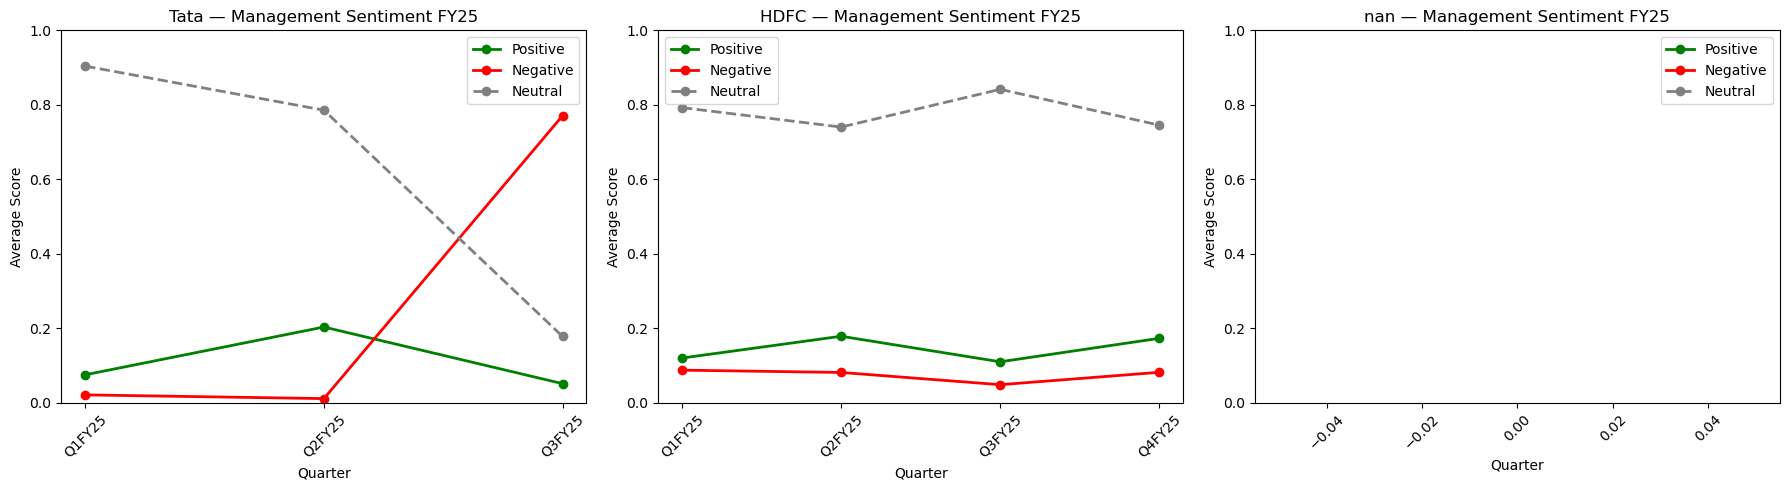

✅ Chart saved


In [9]:
import matplotlib.pyplot as plt

quarter_order = ['Q1FY25', 'Q2FY25', 'Q3FY25', 'Q4FY25']
companies = mgmt_df['ticker'].unique()

fig, axes = plt.subplots(1, len(companies), figsize=(6*len(companies), 5))

if len(companies) == 1:
    axes = [axes]

for i, company in enumerate(companies):
    data = mgmt_df[mgmt_df['ticker'] == company].groupby('quarter')[
        ['positive_score', 'negative_score', 'neutral_score']
    ].mean()
    
    data = data.reindex([q for q in quarter_order if q in data.index])
    
    axes[i].plot(data.index, data['positive_score'], 
                 marker='o', color='green', label='Positive', linewidth=2)
    axes[i].plot(data.index, data['negative_score'], 
                 marker='o', color='red', label='Negative', linewidth=2)
    axes[i].plot(data.index, data['neutral_score'], 
                 marker='o', color='gray', label='Neutral', linewidth=2, linestyle='--')
    axes[i].set_title(f'{company} — Management Sentiment FY25', fontsize=12)
    axes[i].set_xlabel('Quarter')
    axes[i].set_ylabel('Average Score')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("data/sentiment_trend.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

In [10]:
import torch

# Check if MPS (Apple Silicon GPU) is available
if torch.backends.mps.is_available():
    device = "mps"
    print("✅ Apple M4 Neural Engine detected — using MPS acceleration")
else:
    device = "cpu"
    print("Using CPU")

# Reload FinBERT with M5 acceleration
finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    top_k=None,
    device=device    # ← This uses your M4 chip
)

✅ Apple M4 Neural Engine detected — using MPS acceleration


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [11]:

# Check what's happening with HUL
print(mgmt_df['ticker'].value_counts())
print("\nRows where ticker is nan:")
print(mgmt_df[mgmt_df['ticker'].isna()][['speaker', 'utterance']].head(3))

ticker
HDFC    126
Tata      3
Name: count, dtype: int64

Rows where ticker is nan:
    speaker utterance
129     NaN       NaN
130     NaN       NaN
131     NaN       NaN


In [12]:
# Step 1 — Drop empty rows
mgmt_df = mgmt_df.dropna(subset=['ticker', 'utterance'])
print(f"After dropping NaN rows: {len(mgmt_df)} rows")
print(mgmt_df['ticker'].value_counts())

After dropping NaN rows: 129 rows
ticker
HDFC    126
Tata      3
Name: count, dtype: int64


In [13]:
# Step 2 — Check what HUL speakers look like in original data
df_full = pd.read_csv("data/structured_utterances.csv")
hul_df = df_full[df_full['ticker'] == 'HUL']
print(f"\nHUL total utterances: {len(hul_df)}")
print(f"\nHUL role breakdown:")
print(hul_df['role'].value_counts())
print(f"\nHUL unique speakers:")
print(hul_df['speaker'].unique())


HUL total utterances: 369

HUL role breakdown:
role
Analyst      316
Moderator     53
Name: count, dtype: int64

HUL unique speakers:
['Speakers' 'Moderator' 'Yogesh Mulgaonkar' 'Rohit Jawa'
 'Makers.\nLet me take you through some of the key actions that we are driving across each\nportfolio'
 'Lifebuoy.\nLet me demonstrate our strategy in action with the example of the Tea business'
 'Over to you.\nPriya Nair' 'Ritesh Tiwari'
 'The first question is from the line of Abneesh Roy from Nuvama. Please go ahead.\nAbneesh Roy'
 'Abneesh Roy' 'Arnab Mitra' 'Please go ahead.\nLatika Chopra'
 'Laitka Chopra' 'Manoj Menon'
 'Core brand but on the way and Horlicks more work to be done but Boost already\nshowing signs of promise this quarter.\nManoj Menon'
 'Thank you.\nRohit Jawa' 'Please go ahead.\nVivek' 'Vivek' 'Amit'
 'Hindustan Unilever.\nAmit' 'Please go ahead.\nPercy Panthaki'
 'Percy Panthaki' 'Mihir Shah' 'Thank you.\nDisclaimer' 'Priya Nair'
 'Niranjan Gupta'
 'Our first question is f

In [15]:
import pandas as pd

df = pd.read_csv("data/structured_utterances.csv")

def classify_role_v3(speaker_name):
    speaker_lower = str(speaker_name).lower()
    
    moderator_keywords = ['moderator', 'operator', 'coordinator', 'sub', 'speakers']
    
    management_keywords = [
        'ceo', 'cfo', 'coo', 'cto', 'chairman', 'director',
        'president', 'managing', 'executive', 'officer',
        'jagdishan', 'vaidyanathan', 'lakhpatwala',
        'chandrasekaran', 'padmanabhan', 'mistry',
        'jawa', 'tiwari', 'mulgaonkar', 'nair', 'srinivas',
        'mehta', 'khattar', 'gupta', 'rohit', 'ritesh', 'yogesh'
    ]
    
    if any(word in speaker_lower for word in moderator_keywords):
        return 'Moderator'
    elif any(word in speaker_lower for word in management_keywords):
        return 'Management'
    else:
        return 'Analyst'

df['role'] = df['speaker'].apply(classify_role_v3)
df.to_csv("data/structured_utterances.csv", index=False)

print("Updated role breakdown:")
print(df.groupby('role').size())
print("\nHUL management count:")
print(df[(df['ticker']=='HUL') & (df['role']=='Management')].shape[0])

Updated role breakdown:
role
Analyst       456
Management    325
Moderator     162
dtype: int64

HUL management count:
170


In [16]:
mgmt_df = df[df['role'] == 'Management'].copy()
print(f"Management utterances by company:")
print(mgmt_df['ticker'].value_counts())

print("\nRunning FinBERT...")
sentiment_cols = mgmt_df['utterance'].apply(get_sentiment_v2)
mgmt_df = pd.concat([
    mgmt_df[['ticker','quarter','speaker','role','utterance','word_count']].reset_index(drop=True),
    sentiment_cols
], axis=1)

mgmt_df = mgmt_df.dropna(subset=['ticker','utterance'])
mgmt_df.to_csv("data/management_sentiment.csv", index=False)

print("\n✅ Done!")
print("\nSentiment by company:")
print(mgmt_df.groupby(['ticker','sentiment']).size())

Management utterances by company:
ticker
HUL     170
HDFC    129
Tata     26
Name: count, dtype: int64

Running FinBERT...

✅ Done!

Sentiment by company:
ticker  sentiment
HDFC    neutral      31
        positive      7
HUL     negative      2
        neutral      43
        positive      6
Tata    neutral       9
        positive      1
dtype: int64


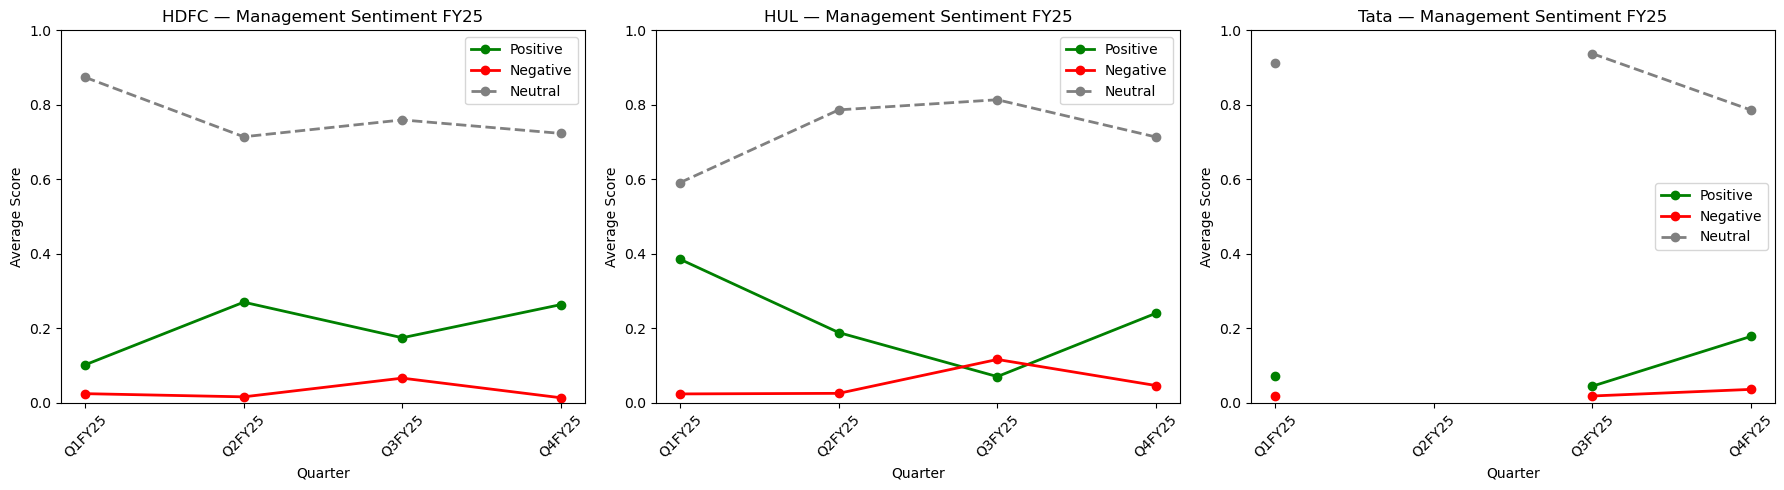

✅ Final chart saved


In [17]:
import matplotlib.pyplot as plt

quarter_order = ['Q1FY25', 'Q2FY25', 'Q3FY25', 'Q4FY25']
companies = ['HDFC', 'HUL', 'Tata']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, company in enumerate(companies):
    data = mgmt_df[mgmt_df['ticker'] == company].groupby('quarter')[
        ['positive_score', 'negative_score', 'neutral_score']
    ].mean().reindex([q for q in quarter_order if q in 
                      mgmt_df[mgmt_df['ticker']==company]['quarter'].values])
    
    axes[i].plot(data.index, data['positive_score'], 
                 marker='o', color='green', label='Positive', linewidth=2)
    axes[i].plot(data.index, data['negative_score'], 
                 marker='o', color='red', label='Negative', linewidth=2)
    axes[i].plot(data.index, data['neutral_score'], 
                 marker='o', color='gray', label='Neutral', 
                 linewidth=2, linestyle='--')
    axes[i].set_title(f'{company} — Management Sentiment FY25', fontsize=12)
    axes[i].set_xlabel('Quarter')
    axes[i].set_ylabel('Average Score')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("data/sentiment_trend_final.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final chart saved")

In [18]:
import torch
from transformers import pipeline

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using: {device}")

finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    top_k=None,
    device=device
)
print("✅ FinBERT loaded")

Using: mps


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ FinBERT loaded


In [19]:
import pandas as pd

mgmt_df = pd.read_csv("data/management_sentiment.csv")
print(f"Total rows: {len(mgmt_df)}")

def get_sentiment_v2(text):
    try:
        text = str(text)[:512]
        scores = finbert(text)[0]
        score_dict = {s['label'].lower(): s['score'] for s in scores}
        dominant = max(score_dict, key=score_dict.get)
        return pd.Series({
            'sentiment': dominant,
            'positive_score': score_dict.get('positive', 0),
            'negative_score': score_dict.get('negative', 0),
            'neutral_score': score_dict.get('neutral', 0),
            'confidence': score_dict[dominant]
        })
    except:
        return pd.Series({
            'sentiment': 'neutral',
            'positive_score': 0,
            'negative_score': 0,
            'neutral_score': 1,
            'confidence': 0
        })

print("Running FinBERT on all 325 rows...")
sentiment_cols = mgmt_df['utterance'].apply(get_sentiment_v2)

# Overwrite sentiment columns with fresh results
mgmt_df['sentiment'] = sentiment_cols['sentiment']
mgmt_df['positive_score'] = sentiment_cols['positive_score']
mgmt_df['negative_score'] = sentiment_cols['negative_score']
mgmt_df['neutral_score'] = sentiment_cols['neutral_score']
mgmt_df['confidence'] = sentiment_cols['confidence']

mgmt_df.to_csv("data/management_sentiment.csv", index=False)
print(f"\n✅ Done!")
print(f"Sentiment breakdown:")
print(mgmt_df['sentiment'].value_counts())
print(f"\nRows with sentiment: {mgmt_df['sentiment'].notna().sum()}")

Total rows: 325
Running FinBERT on all 325 rows...

✅ Done!
Sentiment breakdown:
sentiment
neutral     283
positive     35
negative      7
Name: count, dtype: int64

Rows with sentiment: 325


In [20]:
import os
import torch
import pandas as pd
from transformers import pipeline

os.chdir("/Users/karanrnaik/Desktop/earnings_analyzer")

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using: {device}")

finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    top_k=None,
    device=device
)
print("✅ FinBERT loaded")

Using: mps


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ FinBERT loaded


In [21]:
df = pd.read_csv("data/structured_utterances.csv")
mgmt_df = df[df['role'] == 'Management'].copy().reset_index(drop=True)
print(f"Management utterances: {len(mgmt_df)}")
print(mgmt_df['ticker'].value_counts())

def get_sentiment(text):
    try:
        text = str(text)[:512]
        scores = finbert(text)[0]
        score_dict = {s['label'].lower(): s['score'] for s in scores}
        dominant = max(score_dict, key=score_dict.get)
        return pd.Series({
            'sentiment': dominant,
            'positive_score': score_dict.get('positive', 0),
            'negative_score': score_dict.get('negative', 0),
            'neutral_score': score_dict.get('neutral', 0),
            'confidence': score_dict[dominant]
        })
    except:
        return pd.Series({
            'sentiment': 'neutral',
            'positive_score': 0,
            'negative_score': 0,
            'neutral_score': 1,
            'confidence': 0
        })

print("\nRunning FinBERT on all management utterances...")
sentiment_cols = mgmt_df['utterance'].apply(get_sentiment)
mgmt_df = pd.concat([mgmt_df.reset_index(drop=True), sentiment_cols], axis=1)
mgmt_df.to_csv("data/management_sentiment.csv", index=False)

print("\n✅ Done!")
print("\nSentiment breakdown:")
print(mgmt_df['sentiment'].value_counts())
print("\nBy company:")
print(mgmt_df.groupby(['ticker', 'sentiment']).size().unstack(fill_value=0))

Management utterances: 806
ticker
BAJAJFIN     138
HUL          134
HDFC         133
TCS          116
Tata         116
WIPRO         92
SUNPHARMA     77
Name: count, dtype: int64

Running FinBERT on all management utterances...

✅ Done!

Sentiment breakdown:
sentiment
neutral     663
positive    115
negative     28
Name: count, dtype: int64

By company:
sentiment  negative  neutral  positive
ticker                                
BAJAJFIN          7      121        10
HDFC              6      113        14
HUL               0      116        18
SUNPHARMA         0       70         7
TCS               5       87        24
Tata              5       87        24
WIPRO             5       69        18


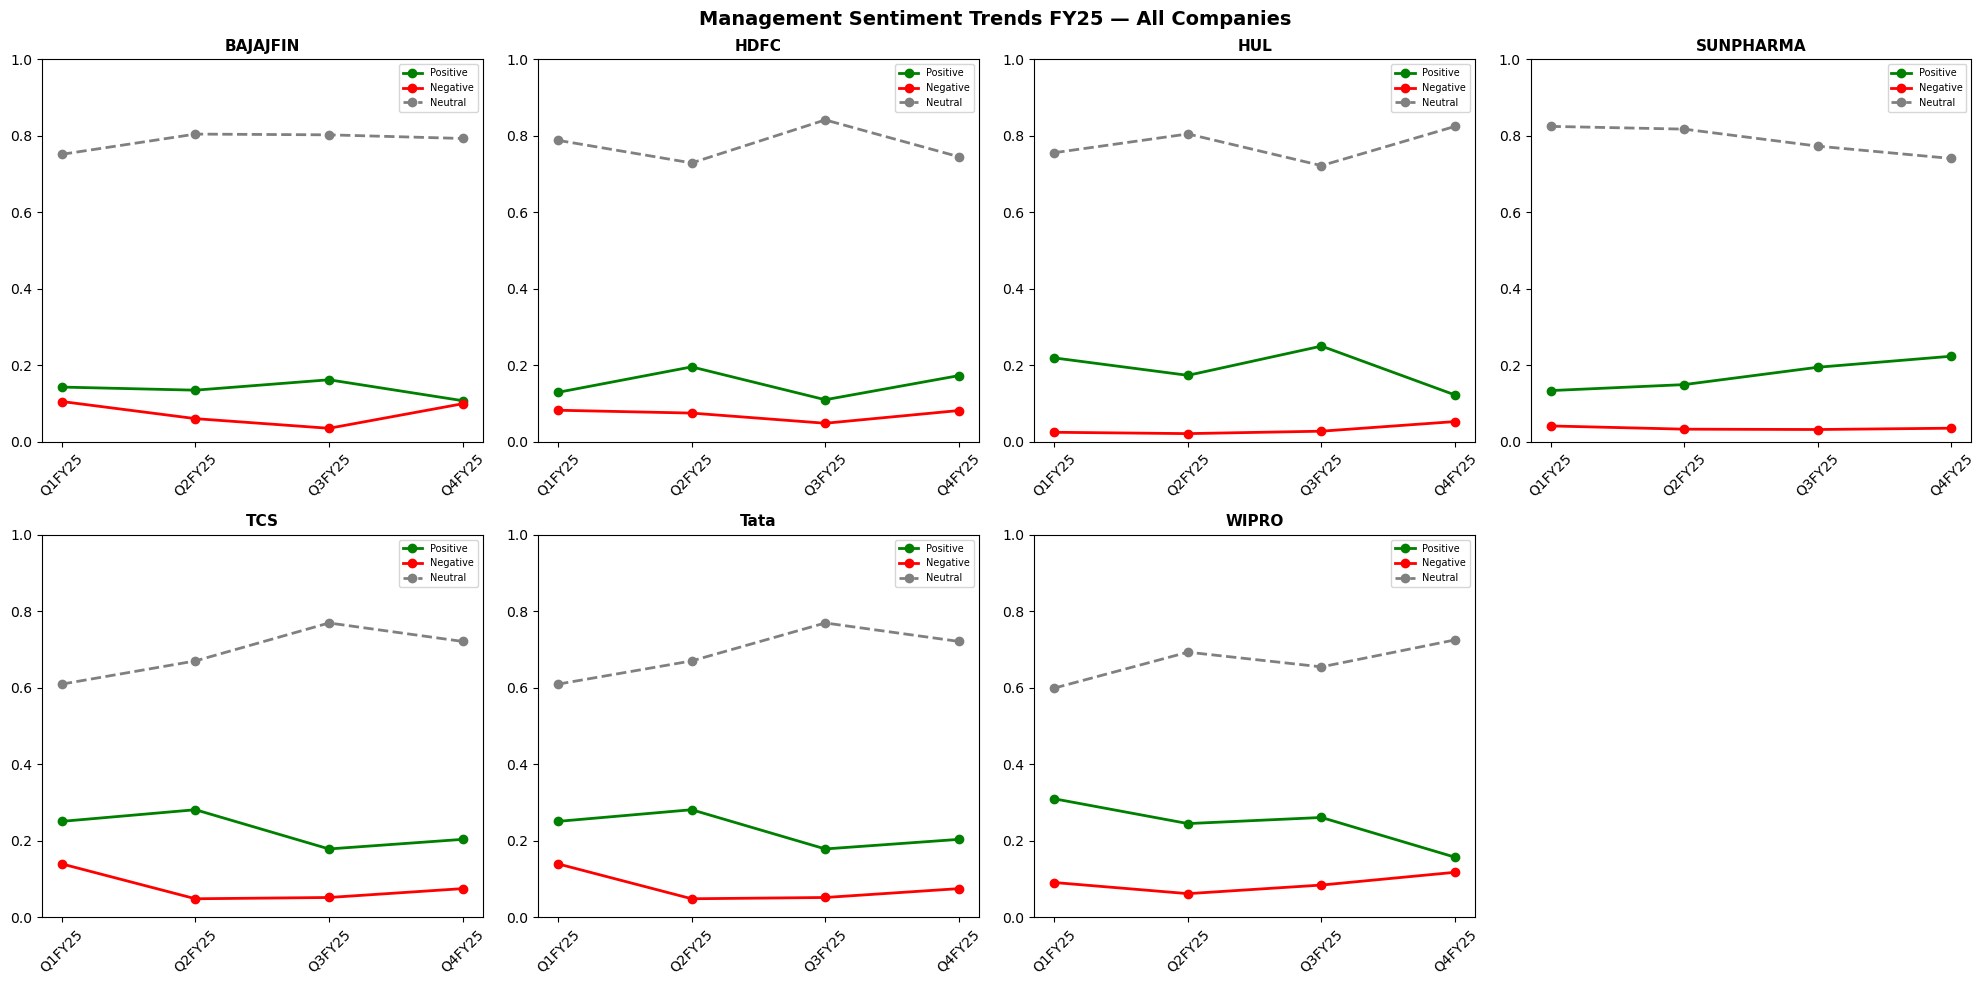

✅ Chart saved


In [22]:
import matplotlib.pyplot as plt

quarter_order = ['Q1FY25', 'Q2FY25', 'Q3FY25', 'Q4FY25']
companies = sorted(mgmt_df['ticker'].unique())

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, company in enumerate(companies):
    data = mgmt_df[mgmt_df['ticker'] == company].groupby('quarter')[
        ['positive_score', 'negative_score', 'neutral_score']
    ].mean()
    data = data.reindex([q for q in quarter_order if q in data.index])

    axes[i].plot(data.index, data['positive_score'],
                 marker='o', color='green', label='Positive', linewidth=2)
    axes[i].plot(data.index, data['negative_score'],
                 marker='o', color='red', label='Negative', linewidth=2)
    axes[i].plot(data.index, data['neutral_score'],
                 marker='o', color='gray', label='Neutral',
                 linewidth=2, linestyle='--')
    axes[i].set_title(f'{company}', fontsize=11, fontweight='bold')
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(fontsize=7)

# Hide unused subplots
for j in range(len(companies), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Management Sentiment Trends FY25 — All Companies',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("data/sentiment_all_companies.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

In [23]:
import os
import torch
import pandas as pd
from transformers import pipeline

os.chdir("/Users/karanrnaik/Desktop/earnings_analyzer")

device = "mps" if torch.backends.mps.is_available() else "cpu"
finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    top_k=None,
    device=device
)
print(f"✅ FinBERT loaded on {device}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ FinBERT loaded on mps


In [24]:
df = pd.read_csv("data/structured_utterances.csv")
mgmt_df = df[df['role'] == 'Management'].copy().reset_index(drop=True)
print(f"Running FinBERT on {len(mgmt_df)} utterances...")

def get_sentiment(text):
    try:
        text = str(text)[:512]
        scores = finbert(text)[0]
        score_dict = {s['label'].lower(): s['score'] for s in scores}
        dominant = max(score_dict, key=score_dict.get)
        return pd.Series({
            'sentiment': dominant,
            'positive_score': score_dict.get('positive', 0),
            'negative_score': score_dict.get('negative', 0),
            'neutral_score': score_dict.get('neutral', 0),
            'confidence': score_dict[dominant]
        })
    except:
        return pd.Series({
            'sentiment': 'neutral',
            'positive_score': 0,
            'negative_score': 0,
            'neutral_score': 1,
            'confidence': 0
        })

sentiment_cols = mgmt_df['utterance'].apply(get_sentiment)
mgmt_df = pd.concat([mgmt_df.reset_index(drop=True), sentiment_cols], axis=1)
mgmt_df.to_csv("data/management_sentiment.csv", index=False)

print("✅ Done!")
print("\nSentiment by company:")
print(mgmt_df.groupby(['ticker','sentiment']).size().unstack(fill_value=0))

Running FinBERT on 873 utterances...
✅ Done!

Sentiment by company:
sentiment  negative  neutral  positive
ticker                                
BAJAJFIN          7      121        10
HDFC              6      115        13
HUL               0      124        19
MARUTI            1       29         2
SUNPHARMA         0       70         7
TCS               6       99        24
Tata              6       99        24
WIPRO             5       71        15


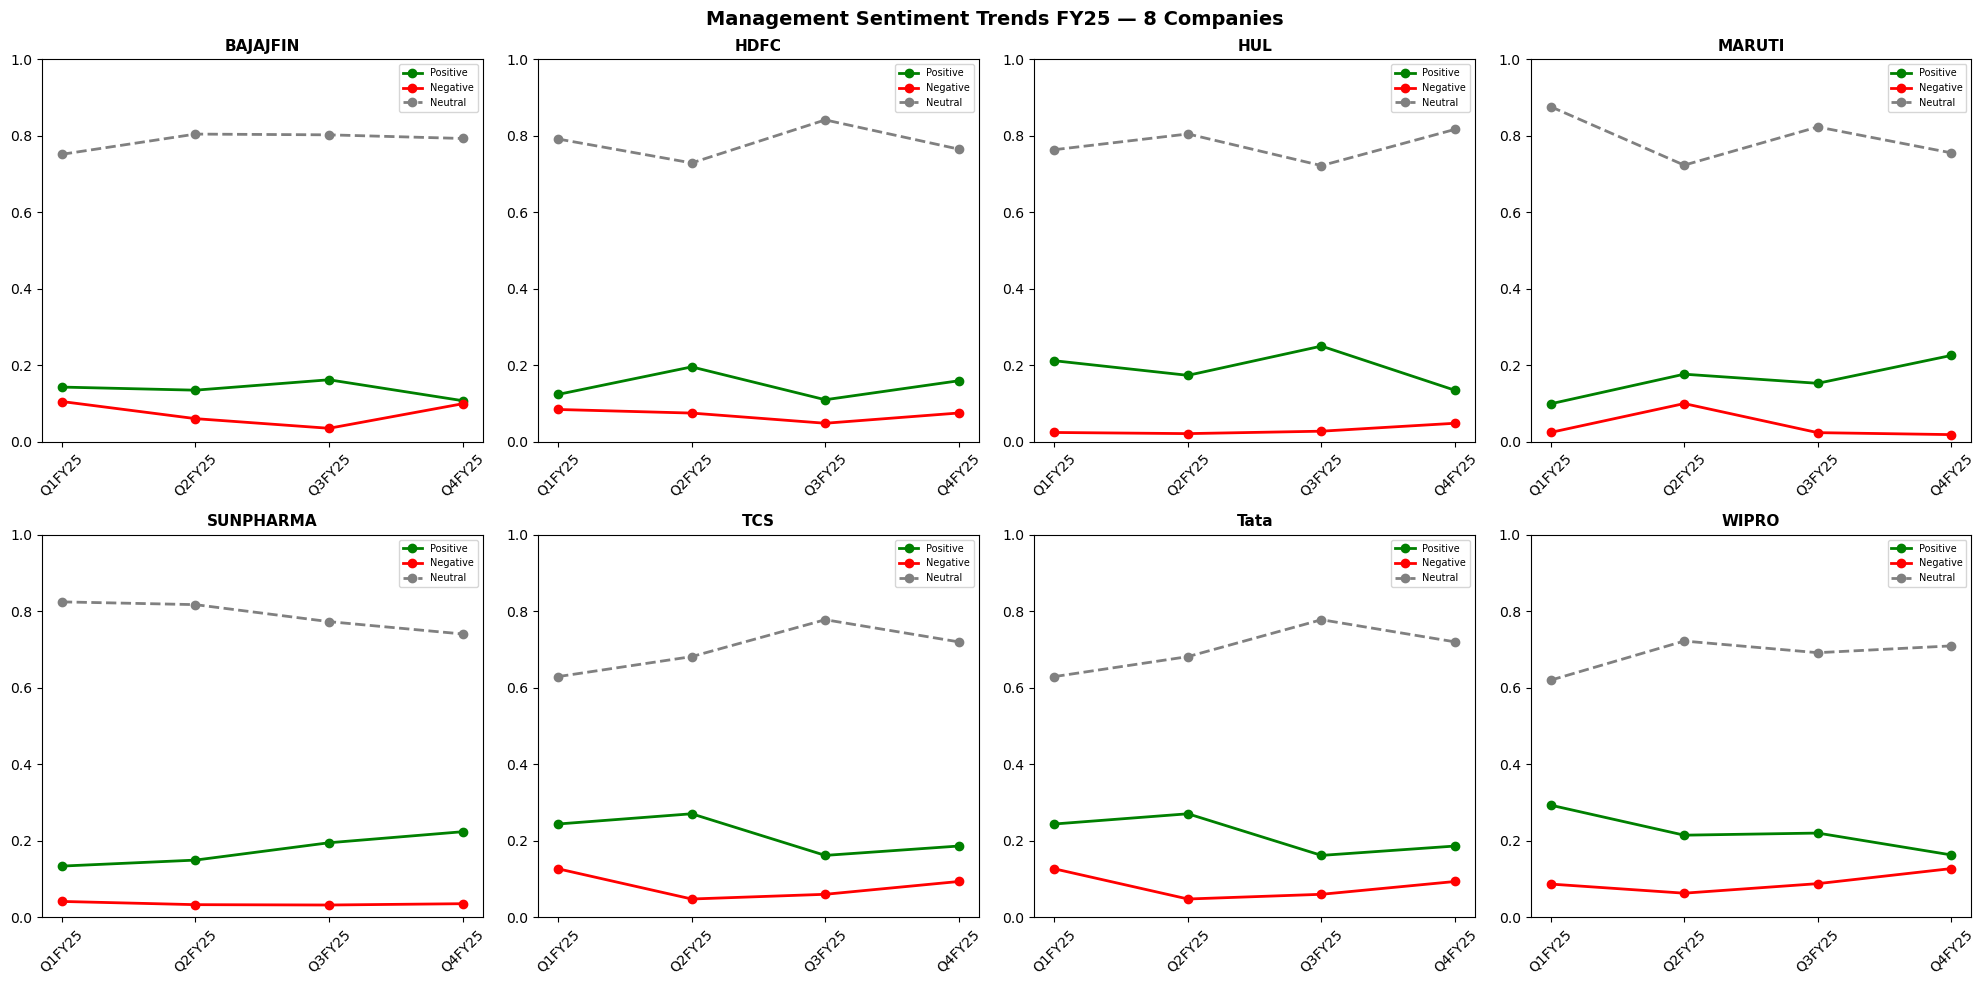

✅ Chart saved


In [25]:
import matplotlib.pyplot as plt

quarter_order = ['Q1FY25', 'Q2FY25', 'Q3FY25', 'Q4FY25']
companies = sorted(mgmt_df['ticker'].unique())

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, company in enumerate(companies):
    data = mgmt_df[mgmt_df['ticker']==company].groupby('quarter')[
        ['positive_score','negative_score','neutral_score']
    ].mean()
    data = data.reindex([q for q in quarter_order if q in data.index])

    axes[i].plot(data.index, data['positive_score'],
                 marker='o', color='green', label='Positive', linewidth=2)
    axes[i].plot(data.index, data['negative_score'],
                 marker='o', color='red', label='Negative', linewidth=2)
    axes[i].plot(data.index, data['neutral_score'],
                 marker='o', color='gray', label='Neutral',
                 linewidth=2, linestyle='--')
    axes[i].set_title(f'{company}', fontsize=11, fontweight='bold')
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(fontsize=7)

plt.suptitle('Management Sentiment Trends FY25 — 8 Companies',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("data/sentiment_all_companies.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")